<a href="https://colab.research.google.com/github/Gnissan-BIA/Assignments/blob/main/Project_part3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#LOAD DATASET

In [23]:
import pandas as pd
import numpy as np

#load dataset

df=pd.read_csv('merged_dataset.csv')
print(df.head())
print()
df.info()

  ticker   open  close  adj_close    low   high   volume  year  decade  \
0    AHH  11.50  11.58   8.493155  11.25  11.68  4633900  2013    2010   
1    AHH  11.66  11.55   8.471151  11.50  11.66   275800  2013    2010   
2    AHH  11.55  11.60   8.507822  11.50  11.60   277100  2013    2010   
3    AHH  11.63  11.65   8.544494  11.55  11.65   147400  2013    2010   
4    AHH  11.60  11.53   8.456484  11.50  11.60   184100  2013    2010   

  exchange                             name   sector     industry  
0     NYSE  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE  
1     NYSE  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE  
2     NYSE  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE  
3     NYSE  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE  
4     NYSE  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180233 entries, 0 to 180232
Data columns (total 13 columns):
 #   Column     Non-Null Count   Dt

#FEATURE ENGINEERING

MACD

In [24]:
df['EMA12'] = df['close'].ewm(span=12, adjust=False).mean()
df['EMA26'] = df['close'].ewm(span=26, adjust=False).mean()

df['MACD'] = df['EMA12'] - df['EMA26']
df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()


In [25]:
#MACD SIgnals
df['MACD_signal'] = 0

df.loc[df['MACD'] > df['Signal_Line'], 'MACD_signal'] = 1   # Buy
df.loc[df['MACD'] < df['Signal_Line'], 'MACD_signal'] = -1  # Sell


In [ ]:
print(df.head())

RSI

In [26]:
delta = df['close'].diff()

gain = (delta.where(delta > 0, 0))
loss = (-delta.where(delta < 0, 0))

avg_gain = gain.ewm(span=14, adjust=False).mean()
avg_loss = loss.ewm(span=14, adjust=False).mean()

rs = avg_gain / avg_loss

df['RSI'] = 100 - (100 / (1 + rs))


In [27]:
#RSI Signals
df['RSI_signal'] = 0

df.loc[df['RSI'] < 30, 'RSI_signal'] = 1   # Buy
df.loc[df['RSI'] > 70, 'RSI_signal'] = -1  # Sell


In [28]:
print(df.head())

  ticker   open  close  adj_close    low   high   volume  year  decade  \
0    AHH  11.50  11.58   8.493155  11.25  11.68  4633900  2013    2010   
1    AHH  11.66  11.55   8.471151  11.50  11.66   275800  2013    2010   
2    AHH  11.55  11.60   8.507822  11.50  11.60   277100  2013    2010   
3    AHH  11.63  11.65   8.544494  11.55  11.65   147400  2013    2010   
4    AHH  11.60  11.53   8.456484  11.50  11.60   184100  2013    2010   

  exchange                             name   sector     industry      EMA12  \
0     NYSE  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE  11.580000   
1     NYSE  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE  11.575385   
2     NYSE  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE  11.579172   
3     NYSE  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE  11.590068   
4     NYSE  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE  11.580827   

       EMA26      MACD  Signal_Line  MACD_signal        RSI  RSI_signal  


In [29]:
print(df.head())

  ticker   open  close  adj_close    low   high   volume  year  decade  \
0    AHH  11.50  11.58   8.493155  11.25  11.68  4633900  2013    2010   
1    AHH  11.66  11.55   8.471151  11.50  11.66   275800  2013    2010   
2    AHH  11.55  11.60   8.507822  11.50  11.60   277100  2013    2010   
3    AHH  11.63  11.65   8.544494  11.55  11.65   147400  2013    2010   
4    AHH  11.60  11.53   8.456484  11.50  11.60   184100  2013    2010   

  exchange                             name   sector     industry      EMA12  \
0     NYSE  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE  11.580000   
1     NYSE  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE  11.575385   
2     NYSE  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE  11.579172   
3     NYSE  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE  11.590068   
4     NYSE  ARMADA HOFFLER PROPERTIES, INC.  FINANCE  REAL ESTATE  11.580827   

       EMA26      MACD  Signal_Line  MACD_signal        RSI  RSI_signal  


Final Trading Signal

In [30]:
df['Final_Signal'] = 0

df.loc[(df['MACD_signal'] == 1) & (df['RSI_signal'] == 1), 'Final_Signal'] = 1
df.loc[(df['MACD_signal'] == -1) & (df['RSI_signal'] == -1), 'Final_Signal'] = -1


In [31]:
print(df.head())

  ticker   open  close  adj_close    low   high   volume  year  decade  \
0    AHH  11.50  11.58   8.493155  11.25  11.68  4633900  2013    2010   
1    AHH  11.66  11.55   8.471151  11.50  11.66   275800  2013    2010   
2    AHH  11.55  11.60   8.507822  11.50  11.60   277100  2013    2010   
3    AHH  11.63  11.65   8.544494  11.55  11.65   147400  2013    2010   
4    AHH  11.60  11.53   8.456484  11.50  11.60   184100  2013    2010   

  exchange  ...   sector     industry      EMA12      EMA26      MACD  \
0     NYSE  ...  FINANCE  REAL ESTATE  11.580000  11.580000  0.000000   
1     NYSE  ...  FINANCE  REAL ESTATE  11.575385  11.577778 -0.002393   
2     NYSE  ...  FINANCE  REAL ESTATE  11.579172  11.579424 -0.000252   
3     NYSE  ...  FINANCE  REAL ESTATE  11.590068  11.584652  0.005417   
4     NYSE  ...  FINANCE  REAL ESTATE  11.580827  11.580603  0.000224   

   Signal_Line  MACD_signal        RSI  RSI_signal  Final_Signal  
0     0.000000            0        NaN           

#DATA PREPARATION

Drop NaNs from rolling features

In [32]:
df = df.dropna()

In [33]:
print(df.head())

  ticker   open  close  adj_close    low   high  volume  year  decade  \
1    AHH  11.66  11.55   8.471151  11.50  11.66  275800  2013    2010   
2    AHH  11.55  11.60   8.507822  11.50  11.60  277100  2013    2010   
3    AHH  11.63  11.65   8.544494  11.55  11.65  147400  2013    2010   
4    AHH  11.60  11.53   8.456484  11.50  11.60  184100  2013    2010   
5    AHH  11.60  11.60   8.507822  11.54  11.60   76800  2013    2010   

  exchange  ...   sector     industry      EMA12      EMA26      MACD  \
1     NYSE  ...  FINANCE  REAL ESTATE  11.575385  11.577778 -0.002393   
2     NYSE  ...  FINANCE  REAL ESTATE  11.579172  11.579424 -0.000252   
3     NYSE  ...  FINANCE  REAL ESTATE  11.590068  11.584652  0.005417   
4     NYSE  ...  FINANCE  REAL ESTATE  11.580827  11.580603  0.000224   
5     NYSE  ...  FINANCE  REAL ESTATE  11.583777  11.582040  0.001736   

   Signal_Line  MACD_signal        RSI  RSI_signal  Final_Signal  
1    -0.000479           -1   0.000000           1     

Features & Target

In [34]:
X = df[['MACD', 'Signal_Line', 'RSI']]
y = df['Final_Signal']


Train-Test Split (Important: No Shuffle)

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


#MODEL BUILDING

Logistic Regression

In [36]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

Random Forest

In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

SVM

In [38]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

SVC()

#MODEL EVALUATION

In [39]:
from sklearn.metrics import classification_report

for model in [lr, rf, svm]:
    preds = model.predict(X_test)
    print(model)
    print(classification_report(y_test, preds))


LogisticRegression(max_iter=1000)
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00        46
           0       1.00      1.00      1.00     35905
           1       0.61      0.26      0.36        96

    accuracy                           1.00     36047
   macro avg       0.54      0.42      0.45     36047
weighted avg       0.99      1.00      1.00     36047

RandomForestClassifier(random_state=42)
              precision    recall  f1-score   support

          -1       0.83      0.11      0.19        46
           0       1.00      1.00      1.00     35905
           1       0.85      0.43      0.57        96

    accuracy                           1.00     36047
   macro avg       0.89      0.51      0.59     36047
weighted avg       1.00      1.00      1.00     36047

SVC()
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00        46
           0       1.00      1.00      1.00     3

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#VISUALIZATION

confusion matrix

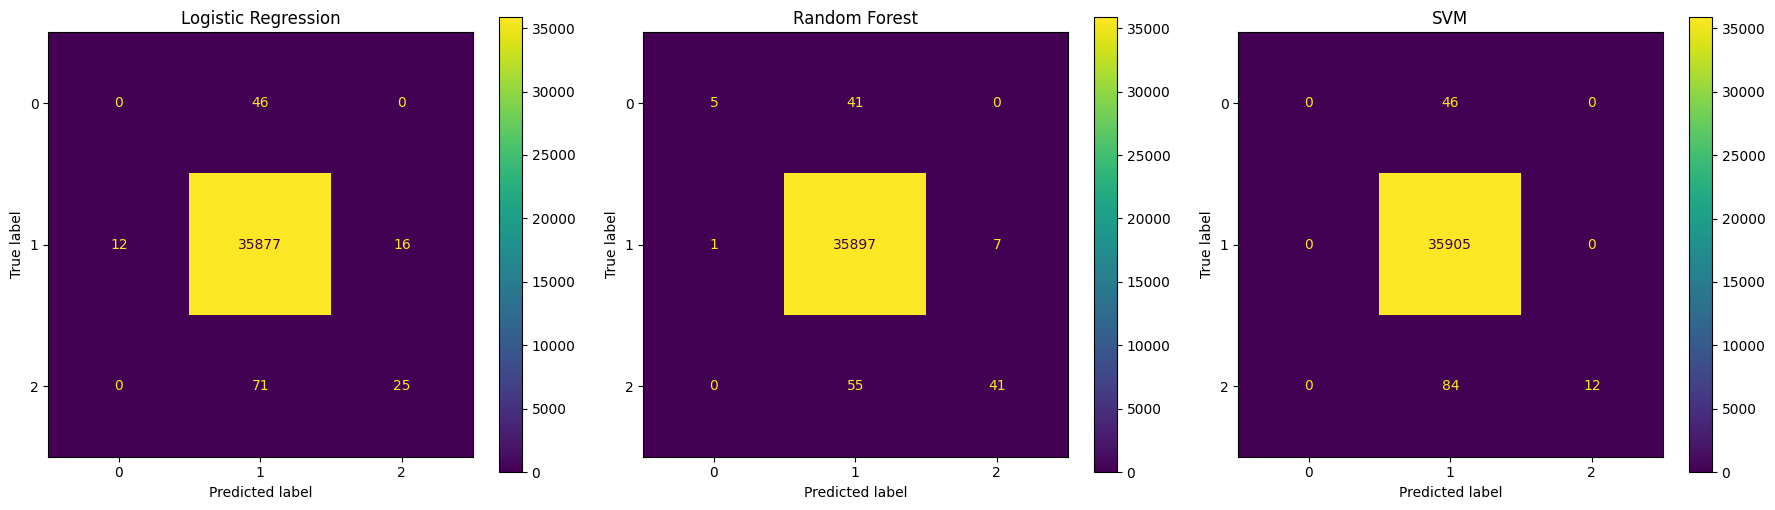

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_svm = svm.predict(X_test)

# Create confusion matrices
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Logistic Regression
ConfusionMatrixDisplay(cm_lr).plot(ax=axes[0])
axes[0].set_title("Logistic Regression")

# Random Forest
ConfusionMatrixDisplay(cm_rf).plot(ax=axes[1])
axes[1].set_title("Random Forest")

# SVM
ConfusionMatrixDisplay(cm_svm).plot(ax=axes[2])
axes[2].set_title("SVM")

plt.tight_layout()
plt.show()


Data Imbalance

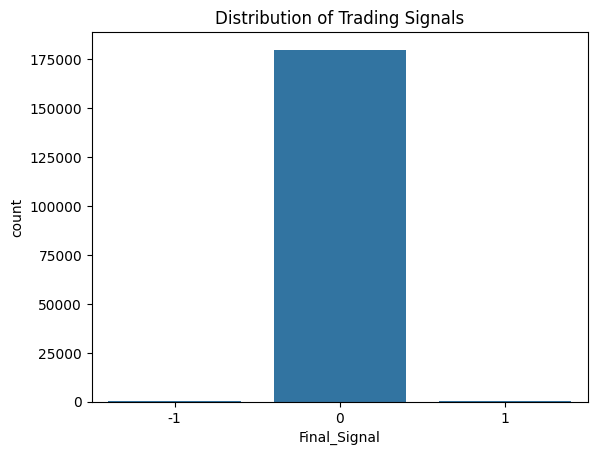

In [44]:
import seaborn as sns

sns.countplot(x=df['Final_Signal'])
plt.title("Distribution of Trading Signals")
plt.show()

#HYPERPARAMETER TUNING

In [46]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 10, 'n_estimators': 50}
